<a href="https://colab.research.google.com/github/prof-atritiack/1CC-MLAM-regressao-linear-CP2-2sem/blob/main/Exemplo_Aula_07_1CCPJ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regressão Linear

Este notebook apresenta uma introdução prática à **correlação** e à **regressão linear**.

A proposta é aprender a:

- observar a relação entre duas variáveis numéricas;
- calcular e interpretar a correlação;
- escolher uma variável de entrada (**X**) e uma variável que queremos estimar (**y**);
- criar um modelo de regressão linear;
- visualizar os dados e a reta ajustada;
- interpretar o coeficiente angular e o intercepto.
- apresentar as métricas do modelo.

Essas etapas servem como referência para a **Challenge Sprint 3**, na qual será necessário selecionar duas variáveis numéricas adequadas e desenvolver uma regressão linear em Python.

## 1. Bibliotecas utilizadas

No Google Colab, as bibliotecas abaixo já estão disponíveis.  
Não é necessário instalar pacotes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Métricas
# R2 = Coeficiente de determinação
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## 2. Dataset

Neste exemplo será utilizada a base **Consumo de Cerveja em São Paulo**.

A base possui informações como temperatura, chuva, final de semana e consumo de cerveja.

Para acompanhar o notebook, o arquivo `consumo.csv` deve estar disponível na sessão do Colab.

In [19]:
dados = pd.read_csv('https://raw.githubusercontent.com/prof-atritiack/1CC-MLAM-regressao-linear-CP2-2sem/refs/heads/main/datasets/base_consumo.csv', sep=";")
dados.head(10)

,data,temp_media,temp_min,temp_max,chuva,fds,consumo
0,01/01/2015,27.30,23.9,32.5,0.0,0,25461
1,02/01/2015,27.02,24.5,33.5,0.0,0,28972
2,03/01/2015,24.82,22.4,29.9,0.0,1,30814
3,04/01/2015,23.98,21.5,28.6,1.2,1,29799
4,05/01/2015,23.82,21.0,28.3,0.0,0,28900
5,06/01/2015,23.78,20.1,30.5,12.2,0,28218
6,07/01/2015,24.00,19.5,33.7,0.0,0,29732
7,08/01/2015,24.90,19.5,32.8,48.6,0,28397
8,09/01/2015,28.20,21.9,34.0,4.4,0,24886
9,10/01/2015,26.76,22.1,34.2,0.0,1,37937


## 3. Conhecendo os dados

Antes de criar um modelo, é importante observar quais informações existem na base.

In [3]:
print("Quantidade de linhas e colunas:", dados.shape)
dados.info()

Quantidade de linhas e colunas: (365, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   data        365 non-null    object 
 1   temp_media  365 non-null    float64
 2   temp_min    365 non-null    float64
 3   temp_max    365 non-null    float64
 4   chuva       365 non-null    float64
 5   fds         365 non-null    int64  
 6   consumo     365 non-null    int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 20.1+ KB


(array([ 2.,  1.,  9.,  7., 17., 35., 37., 35., 43., 31., 29., 25., 25.,
        24., 16., 14.,  7.,  3.,  3.,  2.]),
 array([14343. , 15522.7, 16702.4, 17882.1, 19061.8, 20241.5, 21421.2,
        22600.9, 23780.6, 24960.3, 26140. , 27319.7, 28499.4, 29679.1,
        30858.8, 32038.5, 33218.2, 34397.9, 35577.6, 36757.3, 37937. ]),
 <BarContainer object of 20 artists>)

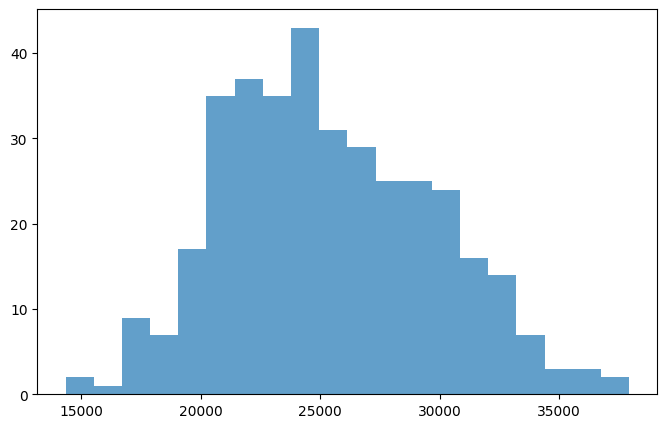

In [4]:
# Histograma da coluna consumo
plt.figure(figsize=(8, 5))
plt.hist(dados["consumo"], bins=20, alpha=0.7)

In [5]:
dados.describe()

,temp_media,temp_min,temp_max,chuva,fds,consumo
count,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000
mean,21.226356,17.461370,26.611507,5.196712,0.284932,25401.367123
std,3.180108,2.826185,4.317366,12.417844,0.452001,4399.142703
min,12.900000,10.600000,14.500000,0.000000,0.000000,14343.000000
25%,19.020000,15.300000,23.800000,0.000000,0.000000,22008.000000
50%,21.380000,17.900000,26.900000,0.000000,0.000000,24867.000000
75%,23.280000,19.600000,29.400000,3.200000,1.000000,28631.000000
max,28.860000,24.500000,36.500000,94.800000,1.000000,37937.000000


## 4. Selecionando apenas as variáveis numéricas

A regressão linear trabalha com valores numéricos.  
Vamos observar as colunas numéricas disponíveis na base.

In [20]:
dados_numericos = dados.select_dtypes(include="number")
dados_numericos.head()

,temp_media,temp_min,temp_max,chuva,fds,consumo
0,27.30,23.9,32.5,0.0,0,25461
1,27.02,24.5,33.5,0.0,0,28972
2,24.82,22.4,29.9,0.0,1,30814
3,23.98,21.5,28.6,1.2,1,29799
4,23.82,21.0,28.3,0.0,0,28900


# Correlação

A **correlação** ajuda a observar a relação linear entre duas variáveis.

O coeficiente de correlação varia de **-1 a +1**:

- valores próximos de **+1** indicam uma relação linear positiva forte;
- valores próximos de **-1** indicam uma relação linear negativa forte;
- valores próximos de **0** indicam uma relação linear fraca ou inexistente.

Uma correlação positiva indica que as duas variáveis tendem a crescer juntas.  
Uma correlação negativa indica que, quando uma aumenta, a outra tende a diminuir.

**Correlação não significa causalidade.**

## 6. Correlação no dataset

Agora podemos calcular a correlação entre as variáveis numéricas da base.

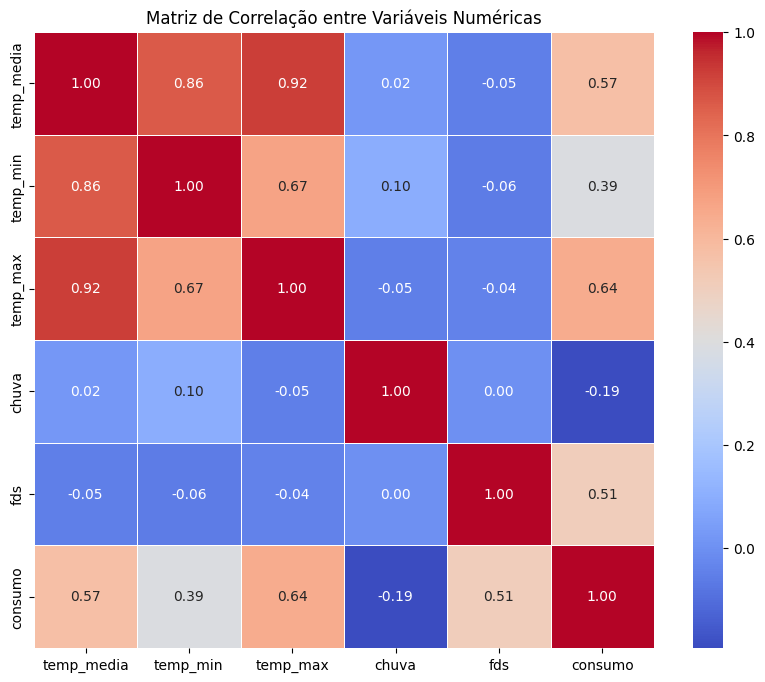

In [7]:
# matriz de correlação usando Seaborn com heatmap
correlacoes = dados_numericos.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlacoes, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlação entre Variáveis Numéricas')
plt.show()

Para facilitar a escolha das variáveis, podemos observar especificamente a relação entre cada variável e o **consumo**.

In [10]:
dados_numericos['fds'].head(14)

,fds
0,0
1,0
2,1
3,1
4,0
5,0
6,0
7,0
8,0
9,1


In [21]:
# Usaremos como features (dataframe X) somente registros de finais de semana
dados_features = dados_numericos[dados_numericos['fds'] == 1]
dados_features.head(10)

,temp_media,temp_min,temp_max,chuva,fds,consumo
2,24.82,22.4,29.9,0.0,1,30814
3,23.98,21.5,28.6,1.2,1,29799
9,26.76,22.1,34.2,0.0,1,37937
10,27.62,22.2,34.8,3.4,1,36254
16,28.86,22.0,35.8,0.0,1,37690
17,28.26,23.4,35.6,0.0,1,30524
23,23.12,19.0,29.4,13.0,1,28348
24,24.40,18.1,30.0,0.0,1,31088
30,21.64,18.5,24.3,0.2,1,27030
31,24.16,20.6,28.0,0.0,1,32057


O método .fit() do modelo de Regressão Linear espera que os dados de entrada (as features, neste caso X_treino) sejam uma matriz 2-dimensional. Mesmo que você tenha apenas uma única feature (como a temp_max), o scikit-learn ainda requer que ela seja fornecida em um formato 2D.

Originalmente, X_treino era uma pandas.Series, que é uma estrutura 1-dimensional. Para transformá-la em uma matriz 2-dimensional, utilizamos o seguinte:

X_treino.values: Converte a Series em um array NumPy.
.reshape(-1, 1): Este método do NumPy remodela o array.
O -1 informa ao NumPy para calcular automaticamente o número de linhas necessário.
O 1 especifica que queremos uma coluna (já que temos apenas uma feature).
Assim, X_treino.values.reshape(-1, 1) transforma sua série de temperaturas máximas em uma matriz com uma coluna e tantas linhas quanto houver valores, atendendo ao formato esperado pelo modelo

In [36]:
X = dados_features[['temp_max']]
X.head()

,temp_max
2,29.9
3,28.6
9,34.2
10,34.8
16,35.8


In [37]:
type(X)

pandas.core.frame.DataFrame

In [38]:
X.shape

(104, 1)

In [24]:
y = dados_features["consumo"]

In [25]:
y.shape

(104,)

In [39]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Registros de treino:", len(X_treino))
print("Registros de teste:", len(X_teste))

Registros de treino: 83
Registros de teste: 21


In [30]:
y_treino

,consumo
192,33298
79,28631
268,29637
156,31129
254,21814
...,...
248,23566
51,30943
324,30392
178,27594


In [29]:
X_treino

,temp_max
192,27.4
79,25.3
268,24.9
156,26.1
254,15.6
...,...
248,19.9
51,31.1
324,24.4
178,21.8


## 10. Criando e treinando o modelo

`LinearRegression()` cria o modelo.

O método `fit()` utiliza os dados de treino para encontrar a reta que melhor representa a relação entre X e y.

In [27]:
modelo = LinearRegression()

In [40]:
modelo.fit(X_treino, y_treino)

LinearRegression()

## 11. Coeficientes da regressão

Uma regressão linear simples pode ser representada por:

**y = aX + b**

onde:

- **b** é o intercepto;
- **a** é o coeficiente angular.

O coeficiente angular indica quanto o valor estimado de **y** tende a mudar quando **X aumenta uma unidade**.

O intercepto representa o valor estimado de **y quando X = 0**. Dependendo do problema, esse valor pode não ter uma interpretação prática.

In [41]:
intercepto = modelo.intercept_
coeficiente = modelo.coef_[0]

print(f"Intercepto: {intercepto:.4f}")
print(f"Coeficiente angular: {coeficiente:.4f}")

Intercepto: 11747.9438
Coeficiente angular: 647.4187


### Exemplo de interpretação

Se o coeficiente angular for positivo, o modelo indica que o consumo estimado tende a aumentar quando a temperatura máxima aumenta.

Se o coeficiente angular for negativo, o modelo indica uma tendência de redução.

A interpretação deve utilizar o **valor obtido na execução do modelo** e as unidades das duas variáveis.

## 12. Fazendo previsões

In [42]:
y_previsao = modelo.predict(X_teste)

In [43]:
resultado = pd.DataFrame({
    "Temperatura máxima": X_teste["temp_max"].values,
    "Consumo real": y_teste.values,
    "Consumo previsto": y_previsao
})

In [44]:
resultado.head(10)

,Temperatura máxima,Consumo real,Consumo previsto
0,29.3,33822,30717.311912
1,27.2,26272,29357.732624
2,27.8,29621,29746.183850
3,14.5,21294,21135.515026
4,26.2,30498,28710.313916
5,28.8,31933,30393.602558
6,29.7,29386,30976.279396
7,27.3,32983,29422.474495
8,28.7,28893,30328.860687
9,29.9,30814,31105.763138


## 13. Gráfico com os dados e a reta ajustada

Este é o tipo de gráfico solicitado na Challenge Sprint 3.

O gráfico deve conter:

- os dados;
- a reta de regressão;
- título;
- identificação dos eixos;
- legenda.

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


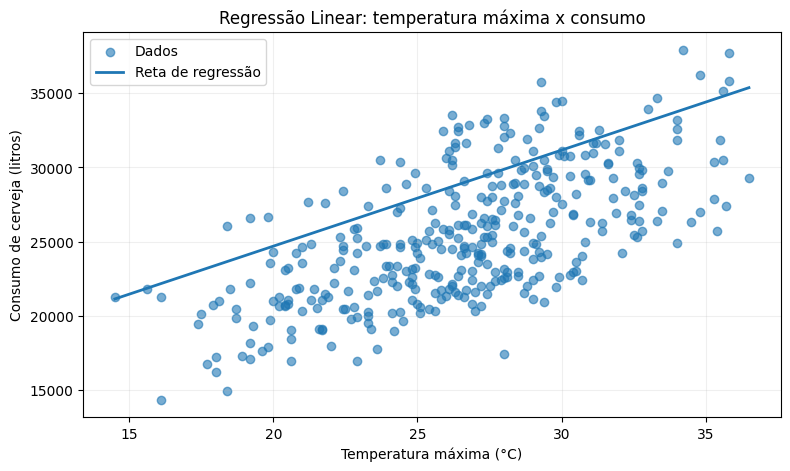

In [45]:
x_reta = np.linspace(
    dados["temp_max"].min(),
    dados["temp_max"].max(),
    100
).reshape(-1, 1)

y_reta = modelo.predict(x_reta)

plt.figure(figsize=(9, 5))

plt.scatter(
    dados["temp_max"],
    dados["consumo"],
    alpha=0.6,
    label="Dados"
)

plt.plot(
    x_reta,
    y_reta,
    linewidth=2,
    label="Reta de regressão"
)

plt.xlabel("Temperatura máxima (°C)")
plt.ylabel("Consumo de cerveja (litros)")
plt.title("Regressão Linear: temperatura máxima x consumo")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

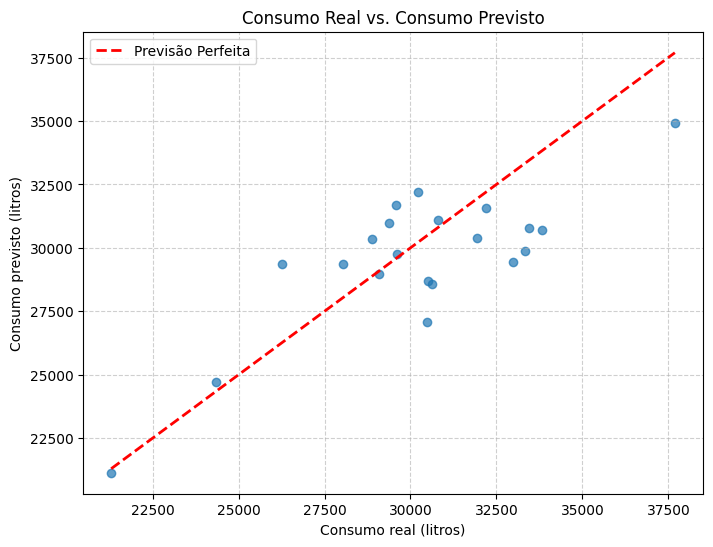

In [46]:
# Gerar o grafico de dispersao de valor real vs valor previsto
plt.figure(figsize=(8, 6))
plt.scatter(resultado['Consumo real'], resultado['Consumo previsto'], alpha=0.7)
plt.plot([resultado['Consumo real'].min(), resultado['Consumo real'].max()],
         [resultado['Consumo real'].min(), resultado['Consumo real'].max()],
         'r--', lw=2, label='Previsão Perfeita')
plt.xlabel('Consumo real (litros)')
plt.ylabel('Consumo previsto (litros)')
plt.title('Consumo Real vs. Consumo Previsto')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

## Métricas para avaliar o modelo

Depois de treinar um modelo de Regressão Linear, podemos utilizar algumas métricas para verificar a qualidade das previsões.

### MAE — Erro Absoluto Médio

O **MAE (Mean Absolute Error)** indica, em média, o quanto as previsões do modelo estão distantes dos valores reais.

Quanto **menor o MAE**, menores são os erros de previsão.

---

### MSE — Erro Quadrático Médio

O **MSE (Mean Squared Error)** calcula a média dos erros elevados ao quadrado.

Por elevar os erros ao quadrado, essa métrica dá **maior peso aos erros grandes**. Por isso, pode ser útil para identificar modelos que apresentam previsões muito distantes dos valores reais.

Quanto **menor o MSE**, melhor o resultado do modelo.

---

### R² — Coeficiente de Determinação

O **R²** indica quanto da variação da variável que queremos prever é explicada pelo modelo, em comparação com uma previsão baseada apenas na média.

Um valor de **R² próximo de 1** indica que o modelo explica bem a variação observada nos dados.

Exemplo:

- **R² = 0,85** → o modelo explica aproximadamente **85% da variação observada** na variável analisada.
- **R² = 0** → o modelo não melhora a explicação em relação ao uso da média.
- **R² < 0** → o modelo apresenta desempenho pior do que utilizar a média como previsão.

O R² deve ser analisado junto com métricas de erro, como **MAE e MSE**, para avaliar melhor o desempenho do modelo.

In [47]:
mae = mean_absolute_error(y_teste, y_previsao)
mse = mean_squared_error(y_teste, y_previsao)
r2 = r2_score(y_teste, y_previsao)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.4f}")

MAE: 1786.49
MSE: 4528179.64
R²: 0.6090


In [ ]:
# Modelos de regressão melhores:
# Maior R2
# Menor MSE e MAE